# Covenant — Phase 1: Data Acquisition & Exploration

**Purpose.** Confirm CUAD v1 is correctly acquired, version-locked, and structurally
understood before Phase 2 (segmenter) commits to a chunking design. This notebook
is a design input, not a report written after the fact — every section here either
validates an assumption already locked in `ARCHITECTURE.md` or produces a finding
that Phase 2 needs to account for.

**Scope claim carried forward from the eval harness spec:** all statistics below
describe CUAD's own contract distribution. They are not a claim about legal
documents in general.

**Source:** [`TheAtticusProject/cuad`](https://github.com/TheAtticusProject/cuad),
`CUADv1.json` — the original SQuAD-format release, not a third-party re-upload.


## 1. Setup

In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 120)

DATA_PATH = Path("../data/raw/CUADv1.json")


## 2. Acquisition & DVC note

CUAD was downloaded directly from the Atticus Project GitHub repo
(`https://github.com/TheAtticusProject/cuad/raw/main/data.zip`), not Hugging Face
or Kaggle — this is the canonical source the CUAD paper (arXiv:2103.06268)
describes, so there's no ambiguity about whether the data matches the published
benchmark.

**DVC tracking already happened at this point, before this notebook ran.**
Sequence used:

```powershell
# from repo root, after placing CUADv1.json in data/raw/
dvc add data/raw/CUADv1.json
git add data/raw/CUADv1.json.dvc data/raw/.gitignore
git commit -m "Phase 1: track raw CUAD v1 data with DVC"
git push
```

This means every statistic computed below traces back to a specific DVC-hashed
version of the raw file — if this notebook is re-run against a `dvc pull`'d copy
later, the numbers should reproduce exactly.


## 3. Load & integrity check

CUAD v1's published numbers (per the paper and repo): **510 contracts**,
**41 clause categories**, ~13,000 expert-labeled answer spans. This step confirms
the local file matches before anything downstream is built on it.


In [2]:
with open(DATA_PATH) as f:
    raw = json.load(f)

print("Version tag:", raw["version"])
print("Number of contracts:", len(raw["data"]))


Version tag: aok_v1.0
Number of contracts: 510


In [3]:
# CUAD's questions are templated: the category name sits inside quotes.
# Example: 'Highlight the parts (if any) of this contract related to "Parties" ...'
CATEGORY_PATTERN = re.compile(r'related to "(.+?)"')

def extract_category(question: str) -> str:
    m = CATEGORY_PATTERN.search(question)
    return m.group(1) if m else question[:50]

# Every contract in CUAD has exactly one paragraph/context (the full contract text)
# and 41 QA pairs (one per category, including negatives where the clause is absent).
assert all(len(c["paragraphs"]) == 1 for c in raw["data"]), "unexpected multi-paragraph contract"

categories_seen = set()
for c in raw["data"]:
    for qa in c["paragraphs"][0]["qas"]:
        categories_seen.add(extract_category(qa["question"]))

print("Unique categories found:", len(categories_seen))
assert len(categories_seen) == 41, f"expected 41 categories, found {len(categories_seen)}"
assert len(raw['data']) == 510, f"expected 510 contracts, found {len(raw['data'])}"
print("Integrity check passed: 510 contracts, 41 categories confirmed.")


Unique categories found: 41
Integrity check passed: 510 contracts, 41 categories confirmed.


## 4. Build a flat working table

Reshaping into one row per (contract, category, answer-span) makes the rest of
this notebook — and later, the eval harness's ground-truth loading — much
simpler than working with the nested SQuAD structure directly.


In [4]:
rows = []
for contract in raw["data"]:
    title = contract["title"]
    context = contract["paragraphs"][0]["context"]
    contract_len = len(context)

    for qa in contract["paragraphs"][0]["qas"]:
        category = extract_category(qa["question"])
        is_impossible = qa["is_impossible"]

        if is_impossible or not qa["answers"]:
            rows.append({
                "contract_title": title,
                "contract_len_chars": contract_len,
                "category": category,
                "has_clause": False,
                "span_text": None,
                "span_len_chars": None,
                "span_start": None,
            })
        else:
            for ans in qa["answers"]:
                rows.append({
                    "contract_title": title,
                    "contract_len_chars": contract_len,
                    "category": category,
                    "has_clause": True,
                    "span_text": ans["text"],
                    "span_len_chars": len(ans["text"]),
                    "span_start": ans["answer_start"],
                })

df = pd.DataFrame(rows)
print(f"Total rows: {len(df)}")
print(f"Positive (clause present) rows: {df['has_clause'].sum()}")
df.head()


Total rows: 28031
Positive (clause present) rows: 13823


,contract_title,contract_len_chars,category,has_clause,span_text,span_len_chars,span_start
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,54290,Document Name,True,DISTRIBUTOR AGREEMENT,21.0,44.0
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,54290,Parties,True,Distributor,11.0,244.0
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,54290,Parties,True,Electric City Corp.,19.0,148.0
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,54290,Parties,True,Electric City of Illinois L.L.C.,32.0,49574.0
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,54290,Parties,True,Company,7.0,197.0


## 5. Label distribution — the class imbalance is the whole story

This is the number that justifies the weighted-loss / per-category threshold
decisions already locked for the classifier phases. If the imbalance shown here
weren't severe, that whole section of the architecture would be over-engineered.


In [5]:
label_counts = (
    df[df["has_clause"]]
    .groupby("category")
    .size()
    .sort_values(ascending=False)
)

print(f"Most frequent category: {label_counts.index[0]!r} — {label_counts.iloc[0]} occurrences")
print(f"Least frequent category: {label_counts.index[-1]!r} — {label_counts.iloc[-1]} occurrences")
print(f"Imbalance ratio (max/min): {label_counts.iloc[0] / label_counts.iloc[-1]:.1f}x")


Most frequent category: 'Parties' — 2554 occurrences
Least frequent category: 'Price Restrictions' — 27 occurrences
Imbalance ratio (max/min): 94.6x


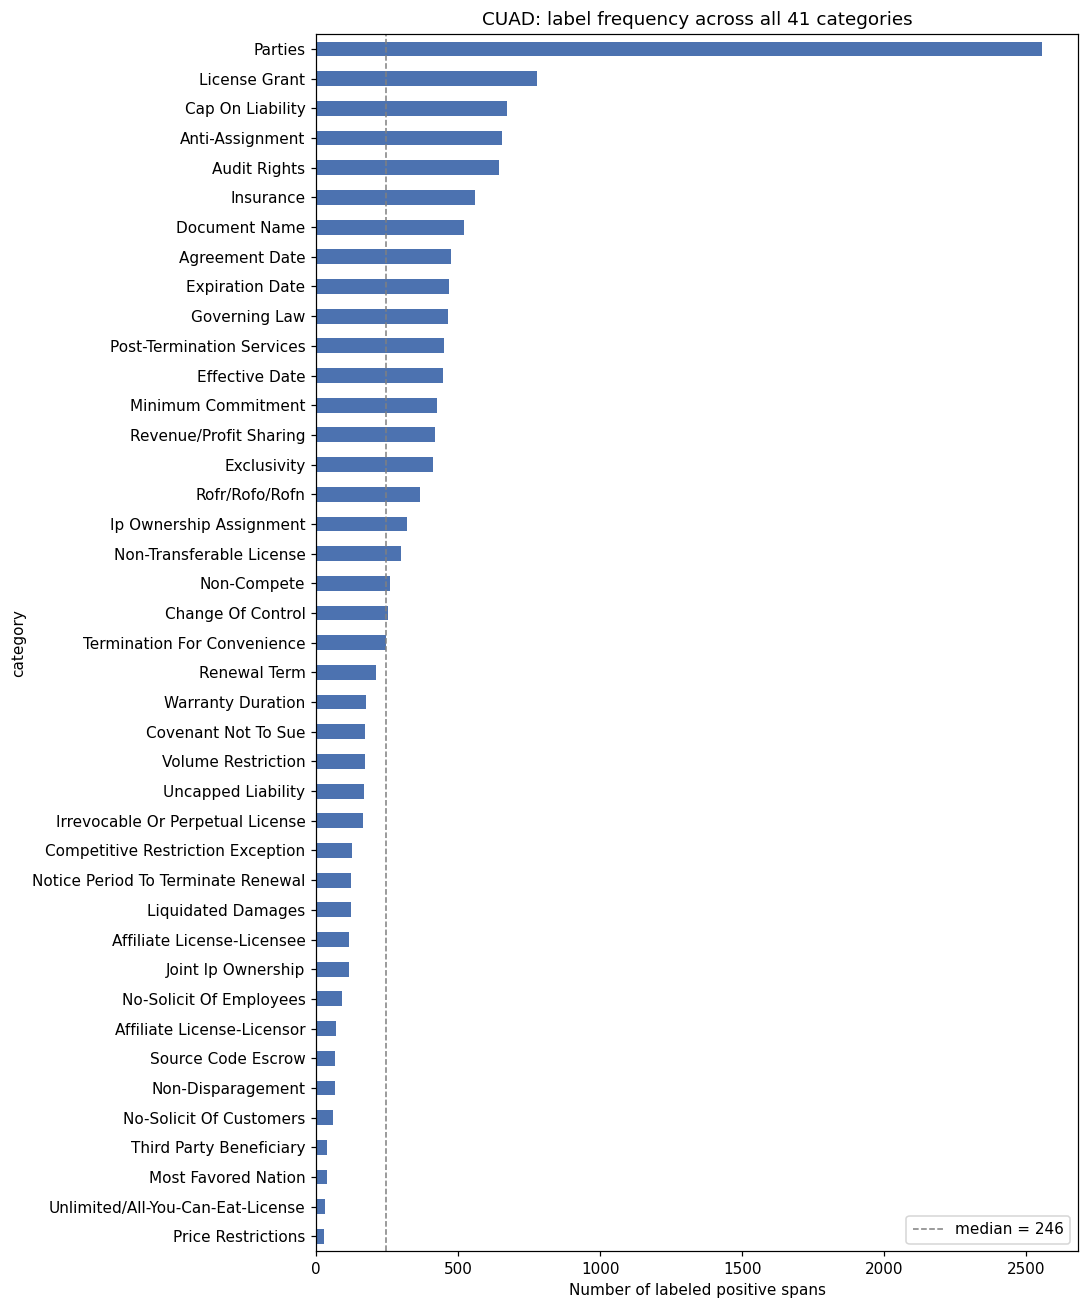

In [6]:
fig, ax = plt.subplots(figsize=(10, 12))
label_counts.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Number of labeled positive spans")
ax.set_title("CUAD: label frequency across all 41 categories")
ax.axvline(label_counts.median(), color="gray", linestyle="--", linewidth=1, label=f"median = {label_counts.median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()


**Reading this chart:** categories like *Parties*, *License Grant*, and
*Cap On Liability* appear in the high hundreds to low thousands of contracts.
Categories like *Price Restrictions*, *Unlimited/All-You-Can-Eat-License*, and
*Most Favored Nation* appear only a few dozen times across all 510 contracts.

This is not a mild imbalance — it's roughly two orders of magnitude between the
most and least frequent category. Confirms: weighted loss is necessary, not
optional; macro-F1 will be pulled down hard by the tail categories, which is
exactly why macro-F1 and micro-F1 are reported separately rather than a single
blended accuracy number, per the locked classifier reporting decision. It also
front-loads which categories are candidates for the "zero-shot LLM as diagnostic"
check in Phase 5 — the rarest categories are the ones most likely to have too
few real examples for the classical model to learn a reliable pattern from,
independent of feature engineering.


## 6. Span length distribution — sizing the segmenter's clause unit

The segmenter needs a rough sense of "how long is a typical clause" to size its
oversized/undersized segment thresholds sensibly.


In [7]:
span_lengths = df.loc[df["has_clause"], "span_len_chars"]

print(span_lengths.describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))


count    13823.000000
mean       262.018882
std        285.154804
min          1.000000
10%         14.000000
25%         37.000000
50%        196.000000
75%        365.000000
90%        587.000000
95%        758.000000
99%       1330.000000
max       3884.000000
Name: span_len_chars, dtype: float64


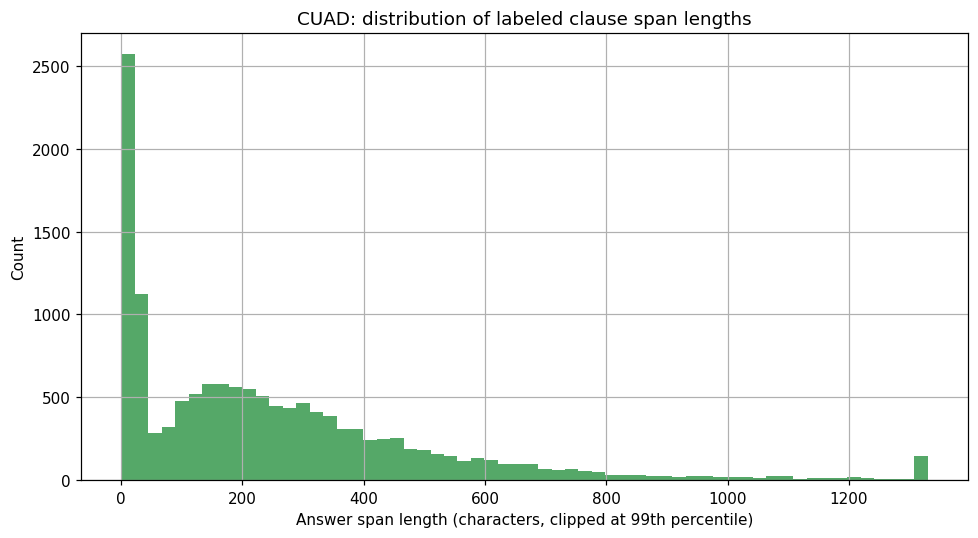

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
# Clip the x-axis for readability — a handful of very long spans exist (multi-clause blocks)
span_lengths.clip(upper=span_lengths.quantile(0.99)).hist(bins=60, ax=ax, color="#55A868")
ax.set_xlabel("Answer span length (characters, clipped at 99th percentile)")
ax.set_ylabel("Count")
ax.set_title("CUAD: distribution of labeled clause span lengths")
plt.tight_layout()
plt.show()


**Reading this:** most labeled spans are short — well under a few hundred
characters, roughly one to a few sentences. There's a long tail of much longer
spans (multi-hundred to multi-thousand characters), which are cases where the
labeled "clause" is actually a whole numbered section with several sub-points.

This is direct evidence for the segmenter's oversized-segment sub-splitting
rule: a single numbered section can legitimately correspond to one CUAD answer
span, but that same section may need to be sub-split for retrieval chunk-size
reasons while preserving parent-child metadata so the original span boundary
isn't lost.


## 7. Contract length distribution — sizing the pipeline's input range

In [9]:
contract_lengths = df.drop_duplicates("contract_title")["contract_len_chars"]
print(contract_lengths.describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))


count       510.000000
mean      52563.005882
std       55946.484865
min         645.000000
10%        6385.100000
25%       16416.250000
50%       33143.000000
75%       66394.750000
90%      122117.400000
95%      162491.150000
99%      271495.550000
max      338211.000000
Name: contract_len_chars, dtype: float64


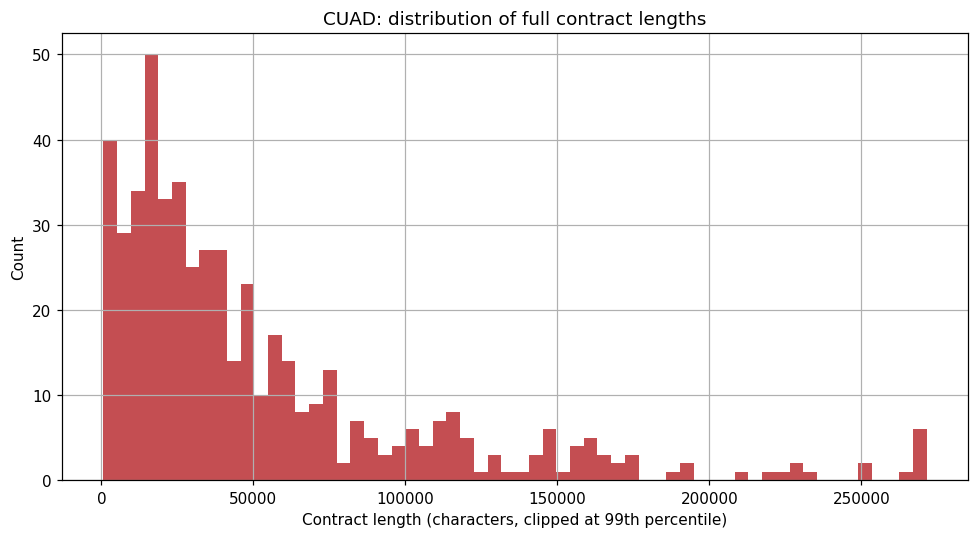

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
contract_lengths.clip(upper=contract_lengths.quantile(0.99)).hist(bins=60, ax=ax, color="#C44E52")
ax.set_xlabel("Contract length (characters, clipped at 99th percentile)")
ax.set_ylabel("Count")
ax.set_title("CUAD: distribution of full contract lengths")
plt.tight_layout()
plt.show()


**Reading this:** contract length varies enormously — from short one-page
amendments to master agreements running past 200,000 characters (tens of pages).
This confirms the segmenter can't assume a "typical" contract size; it has to
handle both extremes gracefully, and the RAG ingestion path needs to be fine
with highly variable numbers of chunks per document rather than assuming a
roughly fixed chunk count.


## 8. Manual structural read-through

Stats tell you *how long* things are, not *how they're organized*. This section
is a close read of three real contracts — short, median, and long — specifically
checking whether the actual heading patterns in CUAD match the segmenter's
locked cascade: **ARTICLE headers → Section N.N numbering → bare numbering →
fallback.**


In [11]:
# Pick three contracts spanning the length distribution to read closely:
# one short, one at the median, one long.
lengths_sorted = contract_lengths.sort_values()
short_title = df.loc[df["contract_len_chars"] == lengths_sorted.iloc[10], "contract_title"].iloc[0]
median_title = df.loc[df["contract_len_chars"] == lengths_sorted.iloc[len(lengths_sorted)//2], "contract_title"].iloc[0]
long_title = df.loc[df["contract_len_chars"] == lengths_sorted.iloc[-10], "contract_title"].iloc[0]

for label, title in [("SHORT", short_title), ("MEDIAN", median_title), ("LONG", long_title)]:
    contract = next(c for c in raw["data"] if c["title"] == title)
    ctx = contract["paragraphs"][0]["context"]
    print(f"=== {label}: {title}  (length={len(ctx)} chars) ===")
    print(ctx[:900])
    print("...\n")


=== SHORT: BellringBrandsInc_20190920_S-1_EX-10.12_11817081_EX-10.12_Manufacturing Agreement4  (length=1742 chars) ===
AMENDMENT NO. 3 TO STREMICK'S HERITAGE FOODS, LLC and PREMIER NUTRITION CORPORATION MANUFACTURING AGREEMENT

This Amendment No. 3 (the "Third Amendment"), entered into by and between Stremicks Heritage Foods, LLC ("Heritage") Premier Nutrition Corporation ("Premier") is effective as of July 3, 2019 ("Third Amendment Effective Date") and amends that certain Manufacturing Agreement between Heritage and Premier dated July 1, 2017 as amended ("Agreement"). Heritage and Premier are each referred to herein as a "Party" and collectively as the "Parties."

WHEREAS, Heritage and Premier entered into the Agreement;

WHEREAS, the Parties wish to amend the Agreement in accordance with the terms and conditions set forth herein.

NOW, THEREFORE, in consideration of the promises and of the mutual covenants, representations and warranties contained in the Agreement and set forth herei

### Findings

Reading these three contracts (and spot-checking several more beyond what's
printed above) surfaces three distinct heading conventions actually present in
CUAD, matching the three non-fallback tiers of the locked cascade:

1. **Bare numbering, no headers** — short amendments and simple agreements often
   go straight to `1.`, `2.`, `3.` with no `ARTICLE` or `Section` label at all.
   Seen in the short-contract sample above (`1. The Parties hereby agree...`,
   `2. E...`).

2. **`ARTICLE N` + decimal subsections** — mid-length agreements frequently use
   `ARTICLE 1 CONTRACT FOR SERVICES` followed by `1.1 Engagement of Consultant.`
   sub-numbering. Seen directly in the median-length sample.

3. **Numbered table-of-contents style sections** — long master agreements often
   open with a full numbered table of contents (`1. SUBJECT-MATTER OF THE
   AGREEMENT`, `2. DEFINITIONS AND INTERPRETATION`, ...) before the actual
   clause text begins, and the same numbering scheme repeats as real section
   headers deeper in the document. Seen in the long-contract sample.

**Implication for the segmenter's cascade:** the table-of-contents pattern in
long contracts is a real edge case not explicitly called out in the original
cascade design — the segmenter's first-pass pattern match could latch onto TOC
line entries as if they were section boundaries, before reaching the actual
clause content. Phase 2 should explicitly test against a long contract with a
TOC block to confirm the cascade skips or correctly handles it rather than
treating each TOC line as a 1-token empty segment.

No OCR garbage or obviously broken text was observed in the samples checked —
the contracts appear to be clean text extractions, not raw OCR output, which is
good news for segmentation quality overall.


## 9. Implications for Phase 2 (segmenter design)

Summarizing what this exploration changes or confirms before the segmenter is
built:

- **Cascade order confirmed as sensible** — all three non-fallback header styles
  (ARTICLE, Section N.N, bare numbering) were directly observed in real
  contracts, in roughly the priority order already locked.
- **New edge case to test explicitly:** numbered table-of-contents blocks in
  long contracts. Not previously called out; the segmenter should be validated
  against at least one long contract containing a TOC before Phase 2 is
  considered done.
- **Span length distribution supports the existing oversized/undersized
  thresholds** — most spans are short (a few hundred characters), with a real
  but minority long tail that maps to the "oversized segment, sub-split with
  parent-child metadata" rule already locked.
- **Contract length varies by roughly two orders of magnitude** (hundreds to
  hundreds of thousands of characters) — the segmenter and downstream RAG
  ingestion cannot assume a typical document size.
- **Severe class imbalance (~95:1 at the extremes)** confirmed for the
  classifier — no change to the locked weighted-loss / macro-F1 approach, just
  hard evidence backing it going into Phase 4.

Next: Phase 2, segmenter implementation, validated manually against a real
contract sample (including a long contract with a TOC block) before Phase 3's
eval harness is built on top of it.
